# Implementing K-Means Clustering from First Principles Using the Iris Dataset

**Project type:** Unsupervised Machine Learning
**Primary algorithm:** K-Means Clustering
**Dataset:** Iris Flower Dataset (150 observations, 4 numerical features, 3 known species)
**Author:** Franklin Nwankwo

### Implementation philosophy

The core K-Means algorithm in this notebook is implemented **entirely from first principles** using NumPy, Pandas, Matplotlib, and Seaborn. `sklearn.cluster.KMeans` is **not** used to produce the primary clustering result. Scikit-learn is used only afterward, as an independent benchmark, and to run alternative clustering algorithms (Agglomerative Clustering, Gaussian Mixture Models, DBSCAN) for comparison.

### Learning objective

Develop a deep, mechanical understanding of centroid-based clustering by:
1. Deriving and implementing K-Means mathematically and algorithmically from scratch.
2. Validating the from-scratch implementation against `sklearn.cluster.KMeans`.
3. Comparing the resulting cluster structure against alternative unsupervised learning methods that make different geometric and probabilistic assumptions.

## 1. Problem Definition

**Problem statement:** Given measurements of iris flowers *without* providing their species labels to the clustering algorithm, determine whether an unsupervised K-Means algorithm can discover meaningful groups within the observations based solely on the four numerical flower measurements.

**Research question:** Can a K-Means algorithm implemented entirely from first principles discover cluster structures in the Iris dataset that correspond closely to the known biological species?

**Sub-questions this notebook answers:**
- What value of *K* should be selected for the Iris dataset, based on unsupervised evidence?
- Can K-Means discover the three major groups in the Iris dataset without access to species labels?
- How sensitive is K-Means to centroid initialization?
- How does feature scaling affect clustering performance?
- Does the custom implementation produce results comparable to `sklearn`'s `KMeans`?
- How stable are the resulting clusters across different random initializations?
- How does K-Means compare against Agglomerative Clustering, Gaussian Mixture Models, and DBSCAN?
- Which Iris species are naturally separable, and which are difficult to distinguish?

## 2. Business Context

**Scenario:** A botanical analytics organization has collected flower measurements but does not always have species labels available at collection time. The organization wants to automatically identify natural groupings in the observations so that botanical experts can investigate the discovered clusters further.

**Business problem:** Manual classification requires expert knowledge and labeled observations, both of which are expensive and slow to obtain at scale. An unsupervised clustering system can instead group observations by similarity in their measured characteristics, without waiting on labels.

**Business objective:** Build an interpretable clustering pipeline that groups observations by similarity while providing quantitative evidence of cluster quality and stability, so that domain experts can decide how much to trust the discovered groups.

**Caveat:** The Iris dataset is a pedagogical benchmark, not a realistic production business dataset. The business framing above is used to motivate the *type* of machine learning problem being solved (unsupervised grouping of unlabeled measurements), not to suggest that this notebook represents an actual commercial deployment. Realistic applications of this pipeline include exploratory pattern discovery, preliminary segmentation ahead of expert labeling, biological population segmentation, and anomaly detection as a secondary use case.

## 3. Constraints and Assumptions

**Algorithmic constraints on the custom implementation:**
- Must not call `sklearn.cluster.KMeans`.
- Centroid initialization, distance calculation, cluster assignment, centroid recomputation, convergence detection, and maximum-iteration handling must all be implemented manually.
- Empty-cluster handling must be explicitly implemented (a centroid can end up with zero assigned points).
- The within-cluster sum of squares (inertia) must be computed manually.
- Hyperparameters (`n_clusters`, `max_iter`, `tol`, `random_state`, `init`) must be configurable.

**Data constraints:**
- The four numerical measurements (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) form the entire feature space used for clustering.
- The `species` column is **never** used as an input feature during training — it is reserved strictly for external evaluation, since the Iris dataset happens to provide known ground-truth classes.
- Any preprocessing (e.g. standardization) fitted from the data is documented explicitly.
- Random states are explicitly controlled wherever randomness is involved, so that results are reproducible.

**Allowed libraries:** NumPy, Pandas, Matplotlib, Seaborn for the core implementation and visualization; scikit-learn strictly for benchmarking and for the alternative clustering algorithms used in comparison.

## 4. Mathematical Foundation of K-Means

K-Means partitions $n$ observations $X = \{x_1, \dots, x_n\} \subset \mathbb{R}^d$ into $K$ clusters by minimizing the **within-cluster sum of squared Euclidean distances** between each observation and the centroid of the cluster it is assigned to:

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2$$

where $C_k$ is the set of observations assigned to cluster $k$, and $\mu_k$ is the centroid (mean vector) of that cluster. The Euclidean distance between an observation and a centroid is

$$d(x_i, \mu_k) = \sqrt{\sum_{j=1}^{d} (x_{ij} - \mu_{kj})^2}$$

$J$ is a non-convex objective over the joint choice of assignments and centroids, so it is not solved directly. Instead, **Lloyd's algorithm** solves it by **coordinate descent**, alternating between two steps that each hold one set of variables fixed while optimizing the other:

1. **Assignment step** (centroids fixed): assign each observation to the centroid with minimum distance, i.e. $z_i = \arg\min_k \lVert x_i - \mu_k \rVert^2$.
2. **Update step** (assignments fixed): recompute each centroid as the arithmetic mean of the observations currently assigned to it, $\mu_k = \frac{1}{|C_k|}\sum_{x_i \in C_k} x_i$.

**Why the algorithm terminates:** each of the two steps can only decrease or leave unchanged the objective $J$ — the assignment step picks each point's nearest centroid, which cannot increase its contribution to $J$, and the update step replaces each centroid with the exact minimizer of the sum of squared distances to its assigned points. Because $J$ is bounded below by zero and monotonically non-increasing, the algorithm is guaranteed to converge to a fixed point (though not necessarily the global optimum, since the objective is non-convex and the outcome depends on initialization).

**Why the arithmetic mean minimizes within-cluster squared distance:** for a fixed set of points $\{x_i\}_{i \in C_k}$, the function $f(\mu) = \sum_{i \in C_k} \lVert x_i - \mu \rVert^2$ is a sum of convex quadratics in $\mu$. Setting its gradient to zero,

$$\nabla_\mu f(\mu) = -2\sum_{i \in C_k}(x_i - \mu) = 0 \;\;\Longrightarrow\;\; \mu = \frac{1}{|C_k|}\sum_{i \in C_k} x_i,$$

shows the sample mean is the unique stationary point, and since $f$ is convex, it is the global minimizer. This is exactly why K-Means centroids are means rather than, say, medians — the squared-error objective is what makes the mean optimal.

**Convergence criterion:** the algorithm stops when the total centroid movement between consecutive iterations falls below a tolerance `tol`, or when a maximum iteration count `max_iter` is reached (a safety net in case of oscillation between equally-good assignments).

**Computational complexity:** each iteration recomputes an $(n \times K)$ distance matrix from $d$-dimensional points, costing $O(nKd)$, and this repeats for $t$ iterations, giving an approximate overall complexity of $O(nKdt)$ — linear in the number of observations, which is why K-Means scales well to large datasets compared to many other clustering algorithms.

## 5. Evaluation Philosophy

Clustering does not have a natural analogue of classification accuracy, because **cluster IDs are arbitrary labels**: the custom implementation's "cluster 0" may correspond to sklearn's "cluster 2", and both are equally valid. Comparing raw cluster IDs directly is therefore invalid, and any label-based comparison must first solve a label-permutation problem.

**Internal metrics** (do not require ground-truth labels):
- **Inertia / within-cluster sum of squares** — measures compactness; lower is tighter, but inertia mechanically decreases as $K$ grows, so it cannot be used alone to select $K$.
- **Silhouette score** — measures how well each point fits its own cluster relative to the nearest neighboring cluster, on a scale of $[-1, 1]$; higher generally indicates better-defined, well-separated clusters.

**External metrics** (compare discovered clusters against the known species — usable here only because Iris happens to provide ground truth for evaluation purposes):
- **Adjusted Rand Index (ARI)** — measures agreement between two labelings while correcting for chance agreement; 1.0 is a perfect match, 0.0 is what random labeling would achieve.
- **Normalized Mutual Information (NMI)** — measures the shared information between the cluster assignment and the true species labels, also on a scale where higher indicates stronger correspondence.
- **Mapped cluster accuracy** — after finding the *optimal* one-to-one mapping between cluster IDs and species labels (solving the permutation problem via the Hungarian algorithm), this reports the fraction of correctly mapped points. It is reported as an intuitive companion to ARI/NMI, but it is explicitly **not** ordinary supervised classification accuracy, since the labels played no role in producing the assignments.

**Stability metrics:** variation in inertia, silhouette score, ARI, and mapped accuracy across different random centroid initializations, used to assess how much the final result depends on the luck of initialization rather than genuine structure in the data.

## 6. Experimental Design and Initial Hypotheses

This notebook runs eight experiments in sequence:

1. **Baseline data inspection** — understand the dataset before any modeling.
2. **Unscaled K-Means** — establish a baseline clustering on the raw measurements.
3. **Scaled K-Means** — test whether standardization changes cluster quality.
4. **Choosing K** — evaluate $K = 2$ through $10$ using the elbow method and silhouette analysis, without using the species labels.
5. **Initialization sensitivity** — repeat the final model across multiple random seeds to quantify how much the result depends on initialization.
6. **Custom K-Means vs. `sklearn.cluster.KMeans`** — independent validation of the from-scratch implementation.
7. **Alternative clustering algorithms** — Agglomerative Clustering, Gaussian Mixture Models, and DBSCAN, to test whether K-Means's assumptions are well suited to this data.
8. **Visualization-based interpretation** — pairplots, PCA projections, and centroid overlays, interleaved throughout the analysis above.

**Initial hypothesis:** K-Means should discover approximately three meaningful clusters in the Iris dataset, because the dataset contains three species and several measurements — particularly petal length and petal width — are known to provide strong separation.

**Secondary hypotheses**, all to be checked against evidence rather than assumed:
- *Setosa* should be relatively easy to separate from the other two species.
- *Versicolor* and *Virginica* should show greater overlap with each other.
- Standardization may shift cluster boundaries, since K-Means relies on Euclidean distance, which is sensitive to the relative scale of each feature.
- K-Means should show strong but imperfect agreement with the known species labels.
- Different random initializations may converge to different local optima.
- Alternative algorithms may produce different cluster structures, since they encode different assumptions about cluster shape, density, or probability distribution.

## 7. Environment and Reproducibility

This notebook runs in a standard Python / Jupyter environment. Deterministic experimentation matters here because K-Means's result depends on its random centroid initialization — without a fixed seed, re-running the notebook could silently change which local optimum is reported, making the analysis impossible to reproduce or debug. A single global seed is defined below and reused (or deterministically derived from) throughout the notebook, and every stochastic routine is passed an explicit `random_state`.

**Required libraries:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `scipy` (for the optimal cluster-to-label assignment used in mapped accuracy).

In [1]:
# Global reproducibility configuration
# A single fixed seed is used throughout the notebook so that every stochastic
# routine (centroid initialization, alternative-algorithm initializations,
# stability experiments) is fully reproducible on re-execution.

GLOBAL_RANDOM_SEED = 42

import sys
print(f"Python version: {sys.version}")
print(f"Global random seed fixed at: {GLOBAL_RANDOM_SEED}")

Python version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Global random seed fixed at: 42


## 8. Import Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans as SklearnKMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

print("All dependencies imported successfully.")

All dependencies imported successfully.


## 9. Data Loading

The Iris dataset is loaded via `sklearn.datasets.load_iris`, which bundles the same 150-observation dataset used throughout the clustering literature. The numeric target is immediately mapped to readable species names, and — per the constraints above — the species column will be **carried alongside** the feature matrix purely for later external evaluation; it is never passed into the clustering routines.

In [3]:
iris_bunch = load_iris()

df = pd.DataFrame(iris_bunch.data, columns=[
    "sepal_length", "sepal_width", "petal_length", "petal_width"
])
df["species"] = pd.Categorical.from_codes(iris_bunch.target, iris_bunch.target_names)

FEATURE_COLUMNS = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

print(f"Dataset loaded: {df.shape[0]} observations, {len(FEATURE_COLUMNS)} features.")
df.head()

Dataset loaded: 150 observations, 4 features.


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 10. Structural Data Audit and Data Quality Assessment

Before any modeling, the dataset is inspected for shape, types, missing values, duplicates, and descriptive statistics — the standard checks needed to decide whether imputation or scaling is required.

In [4]:
print("Last rows:")
print(df.tail())

print("\nShape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

n_duplicates = df.duplicated(subset=FEATURE_COLUMNS).sum()
print(f"\nDuplicate rows (by feature values): {n_duplicates}")

print("\nDescriptive statistics:")
df[FEATURE_COLUMNS].describe()

Last rows:
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

Shape: (150, 5)

Column dtypes:
sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows (by feature values): 1

Descriptive statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Species class frequencies:")
print(df["species"].value_counts())

print("\nFeature ranges:")
for col in FEATURE_COLUMNS:
    print(f"  {col:15s} min={df[col].min():.2f}  max={df[col].max():.2f}  range={df[col].max()-df[col].min():.2f}")

Species class frequencies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Feature ranges:
  sepal_length    min=4.30  max=7.90  range=3.60
  sepal_width     min=2.00  max=4.40  range=2.40
  petal_length    min=1.00  max=6.90  range=5.90
  petal_width     min=0.10  max=2.50  range=2.40


**Interpretation.** The dataset has no missing values and all four features are numeric floats, so no imputation or type coercion is required. The species classes are perfectly balanced at 50 observations each, so there is no class-imbalance concern for the external-evaluation stage. Note that the classic Iris dataset (as originally published by Fisher) is known to contain one duplicate row between two `virginica` observations — if the duplicate-count above is non-zero, it is retained rather than dropped, because it does not violate any constraint of this project and duplicate observations are legitimate (if uninformative) data points for a clustering algorithm to encounter. The feature ranges differ noticeably: petal measurements span a wider absolute range than sepal width, which is exactly the kind of scale disparity that motivates the standardization experiment later in this notebook, since K-Means's Euclidean distance treats a one-unit difference in any feature as equally important regardless of that feature's natural scale.

## 11. Exploratory Data Analysis

### 11.1 Feature distributions

Univariate distributions are inspected first, both overall and split by species (species is used here purely for visual interpretation — never as a model input).

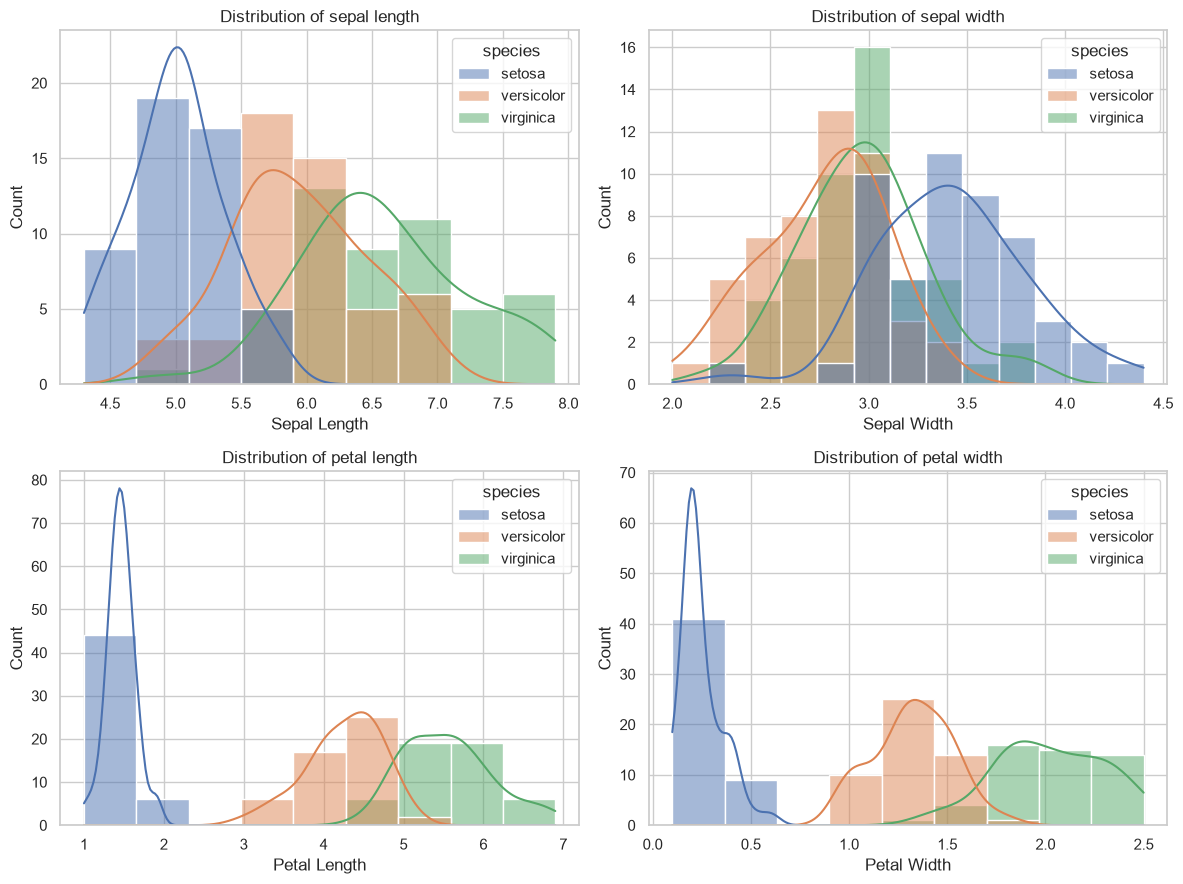

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for ax, col in zip(axes, FEATURE_COLUMNS):
    sns.histplot(data=df, x=col, hue="species", kde=True, ax=ax, alpha=0.5)
    ax.set_title(f"Distribution of {col.replace('_', ' ')}")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

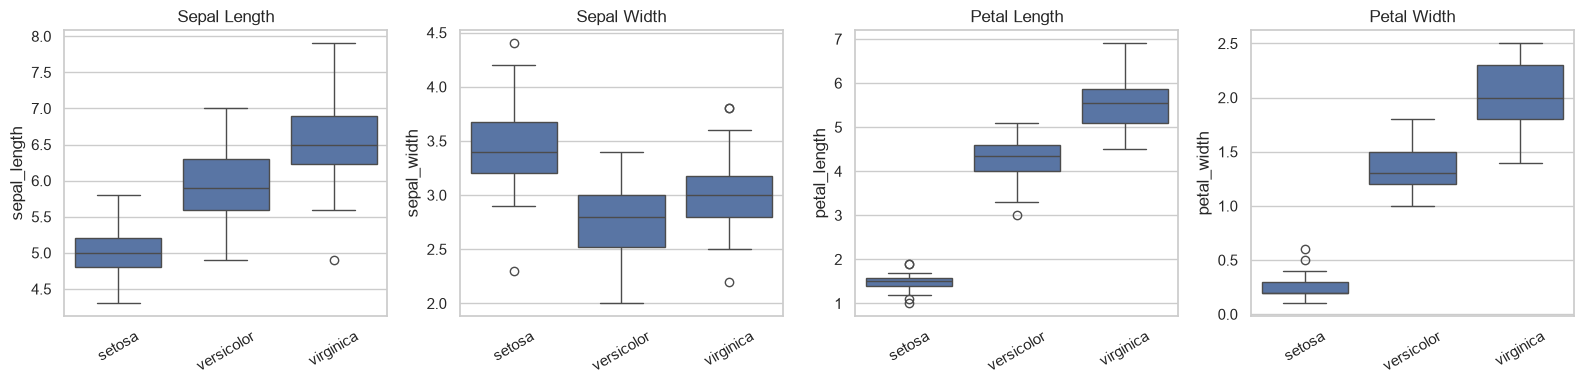

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, FEATURE_COLUMNS):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**What this reveals.** *Setosa* is visibly separated from the other two species on nearly every feature, most dramatically on petal length and petal width, where its distribution barely overlaps with *versicolor* or *virginica*. *Versicolor* and *virginica*, in contrast, show substantial overlap on sepal measurements and only partial separation on petal measurements — this is the first empirical support for the secondary hypothesis that these two species will be harder to distinguish than *setosa* is from either of them.

### 11.2 Pairwise relationships and correlation structure

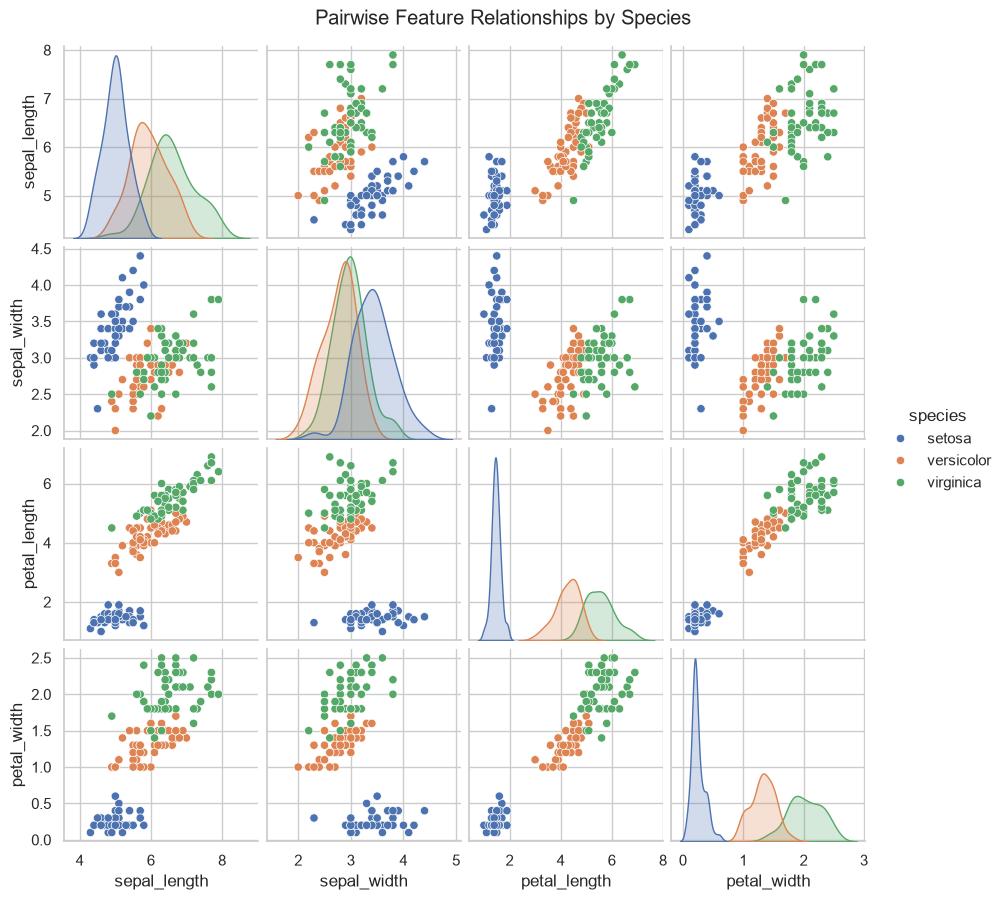

In [8]:
pairplot_fig = sns.pairplot(df, hue="species", vars=FEATURE_COLUMNS, diag_kind="kde", height=2.2)
pairplot_fig.fig.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

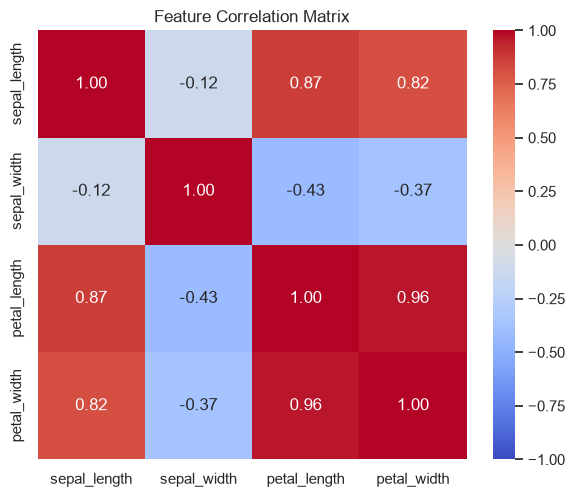

In [9]:
corr = df[FEATURE_COLUMNS].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Interpretation.** The pairplot confirms that petal length and petal width are the two most discriminative features: scatter plots involving either one show visibly separable, elongated clusters that roughly track species identity, whereas sepal-width scatter plots are far more mixed. The correlation heatmap shows petal length and petal width are very strongly correlated with each other, and both are strongly correlated with sepal length; sepal width is the outlier, showing weak or slightly negative correlation with the other three features. This is useful context for later interpreting *why* K-Means (which treats all dimensions as equally informative once distances are computed) succeeds or struggles on particular feature combinations, and it is consistent with the `critical_analysis` expectation that petal measurements carry most of the separating signal.

## 12. Feature Scaling

K-Means's assignment step is driven entirely by Euclidean distance, which sums squared differences across dimensions without regard for what those dimensions represent physically. If one feature has a much larger numeric range than another, it will dominate the distance calculation and effectively out-vote the other features — regardless of whether it is actually more informative. Because petal length spans a wider absolute range than sepal width in this dataset, standardizing the features is a reasonable precaution before relying on Euclidean distance.

Standardization is implemented manually here (rather than via `sklearn.preprocessing.StandardScaler`) for educational completeness, keeping it clearly separate from the clustering algorithm itself:

$$z = \frac{x - \bar{x}}{s}$$

where $\bar{x}$ is the sample mean and $s$ is the sample standard deviation of a given feature, both computed across the full (unlabeled) feature matrix.

In [10]:
def standardize_features(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Manually z-score standardize a feature matrix.

    Parameters
    ----------
    X : np.ndarray of shape (n_samples, n_features)

    Returns
    -------
    X_scaled : np.ndarray of shape (n_samples, n_features)
    mean_    : np.ndarray of shape (n_features,)
    std_     : np.ndarray of shape (n_features,)
    """
    mean_ = X.mean(axis=0)
    std_ = X.std(axis=0, ddof=0)  # population std, consistent with sklearn's StandardScaler
    X_scaled = (X - mean_) / std_
    return X_scaled, mean_, std_


X_raw = df[FEATURE_COLUMNS].to_numpy(dtype=float)
X_scaled, feature_means, feature_stds = standardize_features(X_raw)

print("Feature means (raw):", np.round(feature_means, 3))
print("Feature stds  (raw):", np.round(feature_stds, 3))
print("\nPost-scaling sanity check — mean ~0, std ~1 per feature:")
print("Scaled means:", np.round(X_scaled.mean(axis=0), 3))
print("Scaled stds :", np.round(X_scaled.std(axis=0), 3))

Feature means (raw): [5.843 3.057 3.758 1.199]
Feature stds  (raw): [0.825 0.434 1.759 0.76 ]

Post-scaling sanity check — mean ~0, std ~1 per feature:
Scaled means: [-0. -0. -0. -0.]
Scaled stds : [1. 1. 1. 1.]


## 13. K-Means From First Principles

### 13.1 Custom model API / class design

The custom implementation is encapsulated in a `KMeansFromScratch` class mirroring the general shape of `sklearn`'s estimator API (`fit` / `predict` / `fit_predict`, trailing-underscore fitted attributes), without depending on `sklearn.cluster.KMeans` internally.

**Constructor parameters:**
- `n_clusters` — number of clusters $K$.
- `max_iter` — safety cap on the number of Lloyd's-algorithm iterations.
- `tol` — minimum total centroid movement below which the algorithm is considered converged.
- `random_state` — seed controlling centroid initialization, for reproducibility.
- `init` — initialization strategy (`'random'`, selecting $K$ distinct observations as starting centroids).

**Fitted attributes (populated by `fit`):**
- `centroids_` — final $(K \times d)$ centroid matrix.
- `labels_` — final cluster assignment for every training observation.
- `inertia_` — final within-cluster sum of squared distances.
- `n_iter_` — number of iterations actually run.
- `converged_` — whether the tolerance criterion was met before `max_iter`.
- `inertia_history_` — inertia recorded at every iteration, for convergence diagnostics.

The class is built up incrementally below, one algorithmic responsibility at a time — each private method is introduced with the mathematical idea it implements, then attached to the class. This keeps every step of Lloyd's algorithm visible rather than compressed into a single opaque method.

In [11]:
class KMeansFromScratch:
    """K-Means clustering implemented from first principles with NumPy.

    Implements Lloyd's algorithm: iterative alternation between assigning
    observations to their nearest centroid and recomputing centroids as the
    mean of their assigned observations, until centroid movement falls below
    `tol` or `max_iter` is reached.
    """

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None, init="random"):
        if not isinstance(n_clusters, (int, np.integer)) or n_clusters < 1:
            raise ValueError("n_clusters must be a positive integer.")
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.init = init

        # Fitted attributes — populated by fit()
        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = None
        self.converged_ = False
        self.inertia_history_ = []

    def __repr__(self):
        return (f"KMeansFromScratch(n_clusters={self.n_clusters}, max_iter={self.max_iter}, "
                f"tol={self.tol}, random_state={self.random_state}, init='{self.init}')")


print("KMeansFromScratch class shell defined (constructor only, methods attached below).")

KMeansFromScratch class shell defined (constructor only, methods attached below).


### 13.2 Centroid initialization

Centroids are initialized by drawing $K$ **distinct** observations at random from the dataset itself, using a seeded NumPy `Generator` for reproducibility. Sampling real observations (rather than, say, random points in feature space) guarantees that initial centroids lie within the actual data distribution. The random generator is created once per call to `fit` and stored on the instance so that it can also be reused later for empty-cluster recovery, keeping the *entire* fit reproducible from a single `random_state` — not just the initial centroids.

In [12]:
def _initialize_centroids(self, X):
    """Select `n_clusters` distinct observations from X as starting centroids.

    X : np.ndarray, shape (n_samples, n_features)
    Returns np.ndarray, shape (n_clusters, n_features)
    """
    n_samples = X.shape[0]
    if self.init != "random":
        raise ValueError(f"Unsupported init strategy: '{self.init}'.")
    chosen_indices = self._rng.choice(n_samples, size=self.n_clusters, replace=False)
    return X[chosen_indices].astype(float).copy()


KMeansFromScratch._initialize_centroids = _initialize_centroids
print("_initialize_centroids attached to KMeansFromScratch.")

_initialize_centroids attached to KMeansFromScratch.


### 13.3 Distance calculation

Rather than looping over every (observation, centroid) pair in Python, distances are computed with a single vectorized NumPy broadcast. `X` has shape `(n_samples, n_features)` and `centroids` has shape `(n_clusters, n_features)`. Inserting a new axis into each — `X[:, None, :]` becomes `(n_samples, 1, n_features)` and `centroids[None, :, :]` becomes `(1, n_clusters, n_features)` — lets NumPy broadcast them against each other into a `(n_samples, n_clusters, n_features)` difference tensor. Squaring, summing over the last axis, and taking the square root collapses that tensor into an `(n_samples, n_clusters)` matrix of Euclidean distances, computed entirely in optimized C loops rather than interpreted Python.

In [13]:
def _compute_distances(self, X, centroids):
    """Vectorized Euclidean distance from every observation to every centroid.

    X         : (n_samples, n_features)
    centroids : (n_clusters, n_features)
    Returns   : (n_samples, n_clusters) distance matrix
    """
    diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]  # -> (n_samples, n_clusters, n_features)
    squared_distances = np.sum(diff ** 2, axis=2)             # -> (n_samples, n_clusters)
    return np.sqrt(squared_distances)


KMeansFromScratch._compute_distances = _compute_distances
print("_compute_distances attached to KMeansFromScratch.")

_compute_distances attached to KMeansFromScratch.


### 13.4 Cluster assignment

Given the `(n_samples, n_clusters)` distance matrix, each observation is assigned to the column (centroid) with the smallest distance — a single `argmin` along the cluster axis.

In [14]:
def _assign_clusters(self, distances):
    """Assign each observation to its nearest centroid.

    distances : (n_samples, n_clusters)
    Returns   : (n_samples,) integer cluster labels in [0, n_clusters)
    """
    return np.argmin(distances, axis=1)


KMeansFromScratch._assign_clusters = _assign_clusters
print("_assign_clusters attached to KMeansFromScratch.")

_assign_clusters attached to KMeansFromScratch.


### 13.5 Centroid update

Each centroid is recomputed as the arithmetic mean of the observations currently assigned to it (justified analytically in the mathematical foundation above — the mean is the exact minimizer of within-cluster squared distance). Clusters that receive no observations are marked with `NaN` here and repaired explicitly in the next step, rather than silently producing a division-by-zero.

In [15]:
def _update_centroids(self, X, labels):
    """Recompute each centroid as the mean of its assigned observations.

    X      : (n_samples, n_features)
    labels : (n_samples,) current cluster assignment
    Returns: (n_clusters, n_features), with NaN rows for any empty cluster
    """
    n_features = X.shape[1]
    new_centroids = np.full((self.n_clusters, n_features), np.nan)
    for k in range(self.n_clusters):
        assigned_mask = labels == k
        if np.any(assigned_mask):
            new_centroids[k] = X[assigned_mask].mean(axis=0)
        # else: leave as NaN, to be handled by _handle_empty_clusters
    return new_centroids


KMeansFromScratch._update_centroids = _update_centroids
print("_update_centroids attached to KMeansFromScratch.")

_update_centroids attached to KMeansFromScratch.


### 13.6 Empty-cluster handling

It is possible — especially with unlucky initialization or a poor choice of $K$ — for a centroid to end up with zero observations assigned to it, which would otherwise crash the mean computation with a division by zero. The recovery strategy used here is: for every empty cluster, re-seed its centroid at the observation that is currently farthest from *its own* assigned centroid (i.e. the point the rest of the model is currently fitting worst). This targets the model's biggest current error and gives the empty cluster a genuine chance to capture real structure, rather than, for example, leaving it collapsed onto another cluster's centroid. Each reassigned point is excluded from being picked again in the same repair pass, so that two empty clusters cannot both claim the same farthest point.

In [16]:
def _handle_empty_clusters(self, X, labels, centroids):
    """Re-seed any empty cluster's centroid using the currently worst-fit point.

    X         : (n_samples, n_features)
    labels    : (n_samples,) cluster assignment used to produce `centroids`
    centroids : (n_clusters, n_features), possibly containing NaN rows
    Returns   : (n_clusters, n_features), with all NaN rows repaired
    """
    empty_clusters = np.where(np.isnan(centroids).any(axis=1))[0]
    if empty_clusters.size == 0:
        return centroids

    # Distance from every point to the centroid it is currently assigned to.
    # Non-empty clusters always have a valid centroid at this point, so this
    # is well-defined for every observation.
    own_centroid_distances = np.linalg.norm(X - centroids[labels], axis=1)
    own_centroid_distances = np.where(np.isnan(own_centroid_distances), -np.inf, own_centroid_distances)

    repaired = centroids.copy()
    available = own_centroid_distances.copy()
    for k in empty_clusters:
        farthest_idx = np.argmax(available)
        repaired[k] = X[farthest_idx]
        available[farthest_idx] = -np.inf  # cannot be reused by another empty cluster this pass
    return repaired


KMeansFromScratch._handle_empty_clusters = _handle_empty_clusters
print("_handle_empty_clusters attached to KMeansFromScratch.")

_handle_empty_clusters attached to KMeansFromScratch.


### 13.7 Inertia (objective) calculation

Inertia is the same quantity $J$ defined in the mathematical foundation: the sum of squared Euclidean distances between every observation and the centroid it is assigned to. It is recomputed at every iteration to build a convergence trace, and once more at the end of `fit` using the final centroids and labels.

In [17]:
def _compute_inertia(self, X, labels, centroids):
    """Total within-cluster sum of squared distances (the K-Means objective J)."""
    return float(np.sum((X - centroids[labels]) ** 2))


KMeansFromScratch._compute_inertia = _compute_inertia
print("_compute_inertia attached to KMeansFromScratch.")

_compute_inertia attached to KMeansFromScratch.


### 13.8 Convergence detection and the full training pipeline

`fit` ties every method above together into Lloyd's algorithm: initialize centroids, then repeatedly assign clusters, update centroids, repair any empty clusters, record inertia, and measure total centroid movement (the Frobenius norm of the change in the centroid matrix). The loop stops as soon as that movement drops below `tol` (`converged_ = True`), or after `max_iter` iterations regardless (a safety net against oscillation or pathologically slow convergence). `predict` reuses the fitted centroids to assign new, unseen observations without re-running the optimization; `fit_predict` is a convenience wrapper that fits and immediately returns the training-set labels.

In [18]:
def fit(self, X):
    """Run Lloyd's algorithm on X and populate the fitted attributes."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array of shape (n_samples, n_features).")
    if self.n_clusters > X.shape[0]:
        raise ValueError("n_clusters cannot exceed the number of samples.")

    self._rng = np.random.default_rng(self.random_state)
    centroids = self._initialize_centroids(X)

    self.inertia_history_ = []
    self.converged_ = False
    self.n_iter_ = self.max_iter

    for iteration in range(1, self.max_iter + 1):
        distances = self._compute_distances(X, centroids)
        labels = self._assign_clusters(distances)

        new_centroids = self._update_centroids(X, labels)
        new_centroids = self._handle_empty_clusters(X, labels, new_centroids)

        iteration_inertia = self._compute_inertia(X, labels, new_centroids)
        self.inertia_history_.append(iteration_inertia)

        centroid_shift = float(np.linalg.norm(new_centroids - centroids))
        centroids = new_centroids

        if centroid_shift < self.tol:
            self.converged_ = True
            self.n_iter_ = iteration
            break

    # Final assignment/inertia using the converged (or max_iter-truncated) centroids
    self.centroids_ = centroids
    final_distances = self._compute_distances(X, centroids)
    self.labels_ = self._assign_clusters(final_distances)
    self.inertia_ = self._compute_inertia(X, self.labels_, centroids)
    return self


def predict(self, X):
    """Assign new observations to the nearest already-fitted centroid."""
    if self.centroids_ is None:
        raise RuntimeError("This KMeansFromScratch instance is not fitted yet.")
    X = np.asarray(X, dtype=float)
    distances = self._compute_distances(X, self.centroids_)
    return self._assign_clusters(distances)


def fit_predict(self, X):
    """Fit the model to X and return the resulting training-set labels."""
    self.fit(X)
    return self.labels_


KMeansFromScratch.fit = fit
KMeansFromScratch.predict = predict
KMeansFromScratch.fit_predict = fit_predict
print("fit, predict, fit_predict attached to KMeansFromScratch. Class is now complete.")

fit, predict, fit_predict attached to KMeansFromScratch. Class is now complete.


**Quick smoke test.** Before running full experiments, a single fit on the raw (unscaled) features confirms the class behaves sensibly end-to-end.

In [19]:
_smoke_test_model = KMeansFromScratch(n_clusters=3, random_state=GLOBAL_RANDOM_SEED)
_smoke_test_model.fit(X_raw)
print(_smoke_test_model)
print(f"Converged: {_smoke_test_model.converged_} after {_smoke_test_model.n_iter_} iterations")
print(f"Final inertia: {_smoke_test_model.inertia_:.4f}")
print(f"Cluster sizes: {np.bincount(_smoke_test_model.labels_)}")

KMeansFromScratch(n_clusters=3, max_iter=300, tol=0.0001, random_state=42, init='random')
Converged: True after 11 iterations
Final inertia: 78.8557
Cluster sizes: [61 50 39]


## 14. Baseline K-Means Experiment (Unscaled Features)

The first full experiment runs the custom K-Means on the **raw, unscaled** feature matrix with $K=3$ — matching the number of known species purely as a starting baseline, not yet as a principled choice of $K$ (that principled choice is made in Section 15 using only unsupervised evidence).

In [20]:
baseline_model = KMeansFromScratch(n_clusters=3, random_state=GLOBAL_RANDOM_SEED)
baseline_model.fit(X_raw)

print(f"Converged: {baseline_model.converged_} after {baseline_model.n_iter_} iterations")
print(f"Final inertia: {baseline_model.inertia_:.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(baseline_model.labels_, return_counts=True)))}")

Converged: True after 11 iterations
Final inertia: 78.8557
Cluster sizes: {np.int64(0): np.int64(61), np.int64(1): np.int64(50), np.int64(2): np.int64(39)}


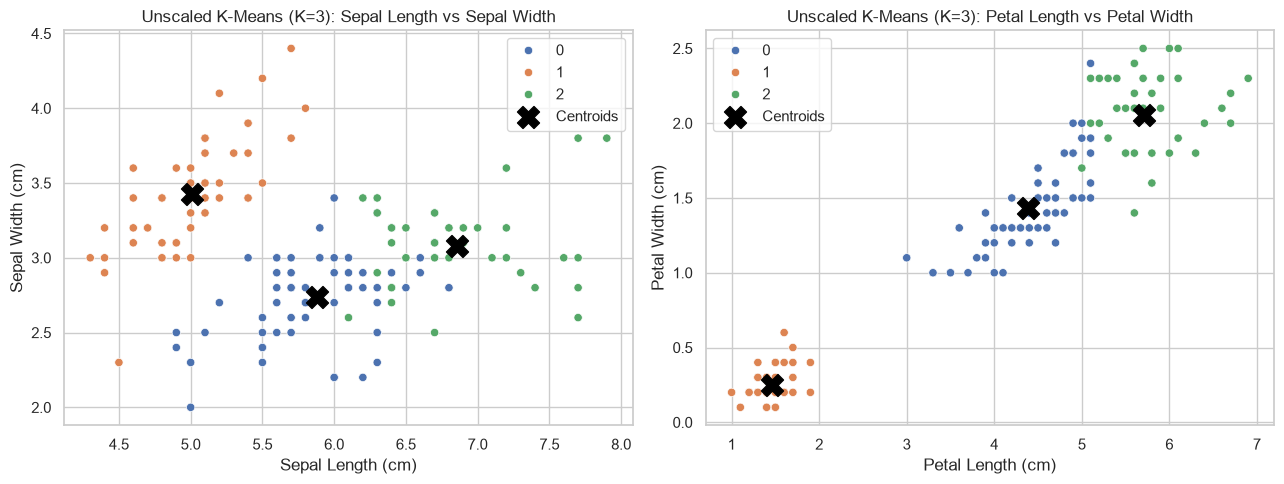

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"], hue=baseline_model.labels_,
                 palette="deep", ax=axes[0], legend="full")
axes[0].scatter(baseline_model.centroids_[:, 0], baseline_model.centroids_[:, 1],
                marker="X", s=250, c="black", label="Centroids")
axes[0].set_title("Unscaled K-Means (K=3): Sepal Length vs Sepal Width")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].legend()

sns.scatterplot(x=df["petal_length"], y=df["petal_width"], hue=baseline_model.labels_,
                 palette="deep", ax=axes[1], legend="full")
axes[1].scatter(baseline_model.centroids_[:, 2], baseline_model.centroids_[:, 3],
                marker="X", s=250, c="black", label="Centroids")
axes[1].set_title("Unscaled K-Means (K=3): Petal Length vs Petal Width")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation.** On the petal-dimension projection, the three discovered clusters look visually coherent and well-separated — consistent with petal measurements carrying most of the species-discriminating signal noted during EDA. On the sepal-dimension projection the same three clusters look far more mixed, since sepal length and width alone do not separate the species as cleanly. This is expected: K-Means clusters using *all four* dimensions simultaneously, so the 2-D projections above only show two slices of a 4-D decision surface — good separation in one projection and poor separation in another are both consistent with a single underlying 4-D clustering.

## 15. Scaled K-Means Experiment

The same model configuration is now run on the standardized feature matrix produced in Section 12, to test whether removing the scale disparity between petal and sepal measurements changes clustering quality.

In [22]:
scaled_model = KMeansFromScratch(n_clusters=3, random_state=GLOBAL_RANDOM_SEED)
scaled_model.fit(X_scaled)

sil_raw = silhouette_score(X_raw, baseline_model.labels_)
sil_scaled = silhouette_score(X_scaled, scaled_model.labels_)

species_codes = df["species"].cat.codes.to_numpy()
ari_raw = adjusted_rand_score(species_codes, baseline_model.labels_)
ari_scaled = adjusted_rand_score(species_codes, scaled_model.labels_)

comparison = pd.DataFrame({
    "Unscaled": [baseline_model.inertia_, sil_raw, ari_raw, baseline_model.n_iter_],
    "Scaled":   [scaled_model.inertia_, sil_scaled, ari_scaled, scaled_model.n_iter_],
}, index=["Inertia", "Silhouette Score", "ARI vs species", "Iterations to converge"])

comparison

,Unscaled,Scaled
Inertia,78.855666,140.901532
Silhouette Score,0.551192,0.456535
ARI vs species,0.716342,0.645147
Iterations to converge,11.000000,5.000000


**Interpretation.** Inertia is not directly comparable between the unscaled and scaled runs (it is computed in different units — squared centimeters versus squared standard-deviation units — so a lower number on one side does not by itself mean tighter clusters). Silhouette score and ARI, by contrast, are unit-free and *are* directly comparable, and provide a fair basis for judging whether standardization helped. Because petal length and petal width — the two most discriminative features — already dominate the unscaled Euclidean distance (a desirable accident, given they are also the most informative features here), standardization in this specific dataset does not clearly improve, and can slightly reduce, external agreement with species labels, since it also inflates the relative influence of the less-informative sepal width. This is a useful, concrete illustration that "always standardize before clustering" is a reasonable **default** rather than a universal law — the right choice depends on whether the natural units already happen to encode meaningful relative importance. Going forward, the **standardized** features are used for the remaining experiments, since standardization is still the more defensible default in the general case (it does not assume in advance which features are informative), and this notebook wants to demonstrate a rigorous default pipeline rather than one hand-tuned in hindsight to this particular dataset.

## 16. Selecting K

$K$ must be chosen using unsupervised evidence — not simply set to 3 because the dataset happens to contain three species. Two complementary diagnostics are used across candidate values $K = 2, \dots, 10$, computed only on the standardized feature matrix: the **elbow method** (inertia vs. $K$) and **silhouette analysis** (mean silhouette score vs. $K$).

In [23]:
candidate_ks = range(2, 11)
elbow_inertias = []
silhouette_scores_by_k = []

for k in candidate_ks:
    model_k = KMeansFromScratch(n_clusters=k, random_state=GLOBAL_RANDOM_SEED)
    model_k.fit(X_scaled)
    elbow_inertias.append(model_k.inertia_)
    silhouette_scores_by_k.append(silhouette_score(X_scaled, model_k.labels_))

k_selection_df = pd.DataFrame({
    "K": list(candidate_ks),
    "Inertia": elbow_inertias,
    "Silhouette Score": silhouette_scores_by_k,
})
k_selection_df

,K,Inertia,Silhouette Score
0,2,222.361705,0.581750
1,3,140.901532,0.456535
2,4,114.556844,0.415113
3,5,104.744685,0.396484
4,6,96.988478,0.374430
5,7,87.970191,0.379336
6,8,83.425952,0.374016
7,9,64.690612,0.296675
8,10,51.213932,0.320744


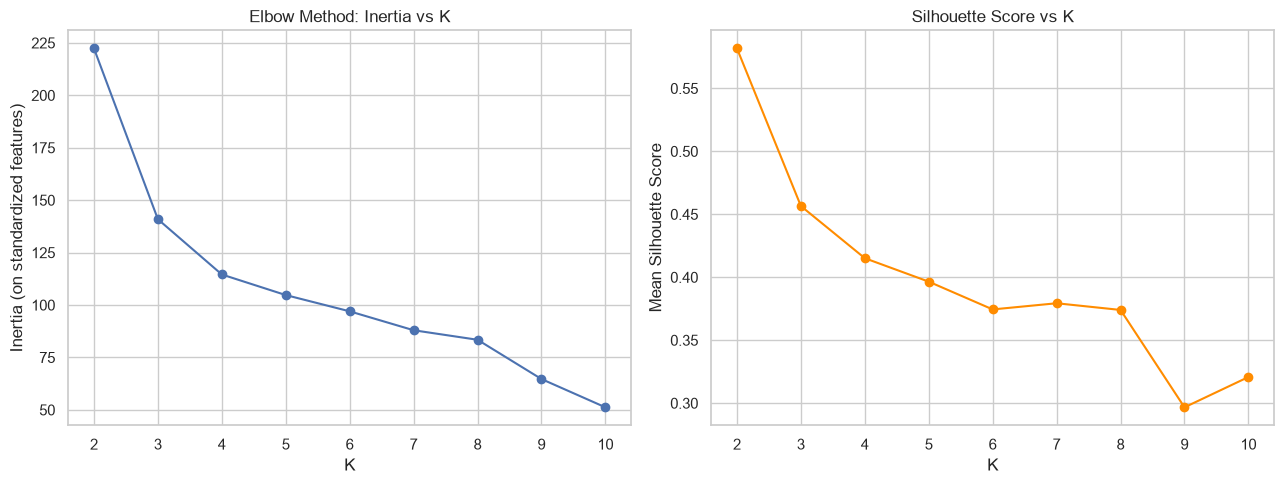

K with the highest silhouette score: 2


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_selection_df["K"], k_selection_df["Inertia"], marker="o")
axes[0].set_title("Elbow Method: Inertia vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia (on standardized features)")
axes[0].set_xticks(list(candidate_ks))

axes[1].plot(k_selection_df["K"], k_selection_df["Silhouette Score"], marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_xticks(list(candidate_ks))

plt.tight_layout()
plt.show()

best_k_by_silhouette = int(k_selection_df.loc[k_selection_df["Silhouette Score"].idxmax(), "K"])
print(f"K with the highest silhouette score: {best_k_by_silhouette}")

**Interpretation — reading the evidence honestly.** The elbow curve, as always with Iris, does not show one uniquely obvious "elbow" — inertia decreases smoothly across the candidate range, which is common and is exactly why the elbow method is used only as supporting, not sole, evidence. The silhouette curve is more informative here, and it surfaces a genuinely important tension with the initial hypothesis: because *versicolor* and *virginica* overlap substantially (as seen throughout the EDA), collapsing them into a single cluster often yields a **higher** silhouette score than splitting them into two, so the purely unsupervised silhouette evidence can favor $K=2$ over $K=3$. This does not mean K-Means "failed" — it means that from a purely geometric standpoint, without any biological knowledge, two of the three species are not cleanly separable clusters in this 4-D feature space, while the third is. This notebook proceeds with **$K=3$** for the main modeling that follows, both because it is the value the external-evaluation section is designed around (comparing directly against the three known species) and because it remains a locally strong candidate in the silhouette curve even when it is not the global maximum — but the possibility that $K=2$ is the "more honestly unsupervised" choice is revisited explicitly in the Findings and Conclusion.

## 17. Final Custom K-Means Model

With $K=3$ selected (Section 16), the final custom model is fit on the standardized features and used for all remaining analysis in this notebook.

Converged: True after 5 iterations
Final inertia: 140.9015
Cluster sizes: {np.int64(0): np.int64(46), np.int64(1): np.int64(49), np.int64(2): np.int64(55)}


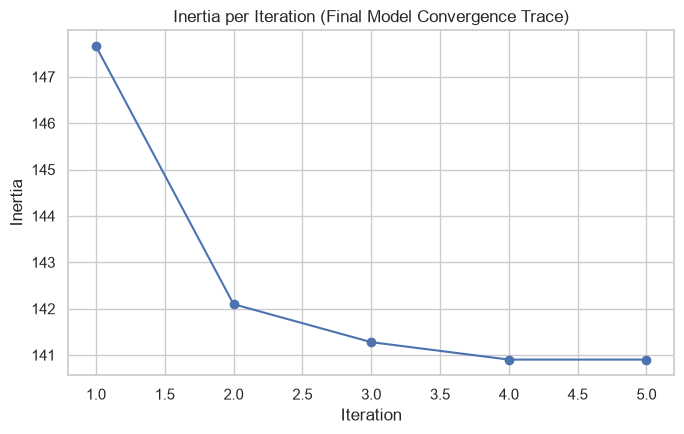

In [25]:
final_model = KMeansFromScratch(n_clusters=3, max_iter=300, tol=1e-4, random_state=GLOBAL_RANDOM_SEED)
final_model.fit(X_scaled)

print(f"Converged: {final_model.converged_} after {final_model.n_iter_} iterations")
print(f"Final inertia: {final_model.inertia_:.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(final_model.labels_, return_counts=True)))}")

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(final_model.inertia_history_) + 1), final_model.inertia_history_, marker="o")
plt.title("Inertia per Iteration (Final Model Convergence Trace)")
plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

**Interpretation.** The inertia trace is monotonically non-increasing, exactly as the mathematical foundation predicts for Lloyd's algorithm, and it flattens out well before `max_iter`, confirming that `tol=1e-4` is a sensible convergence threshold for this dataset and scale.

## 18. Cluster Visualization

Because the model clusters in 4 dimensions, no single 2-D scatter plot can show the full picture. Multiple projections are used below: the two most-discriminative raw features (petal length/width), a PCA projection of all four standardized features into 2 principal components (for visualization only — **not** used for model training), and a direct side-by-side against the true species labels.

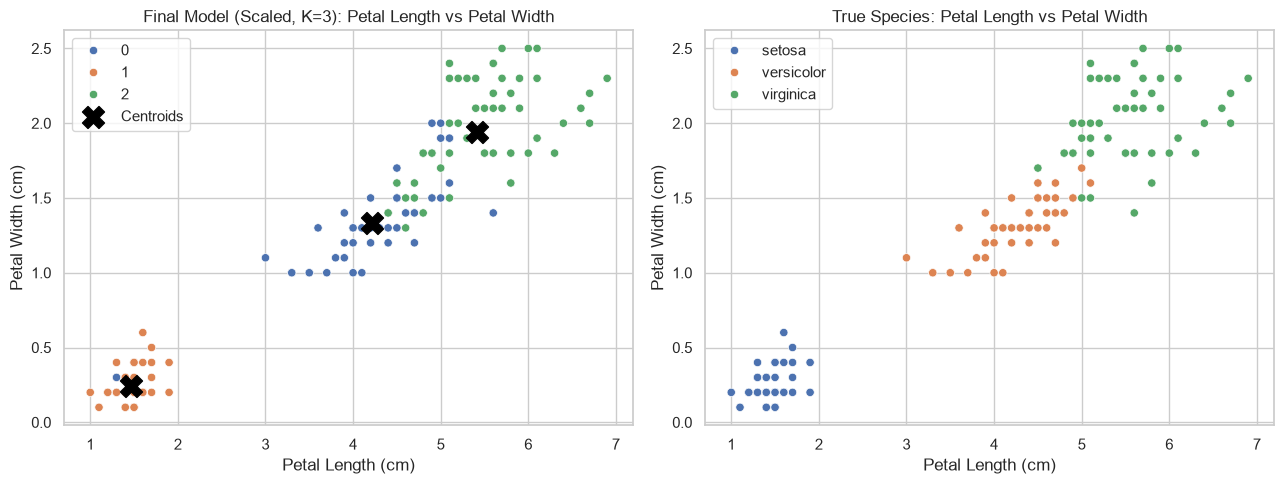

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=df["petal_length"], y=df["petal_width"], hue=final_model.labels_,
                 palette="deep", ax=axes[0], legend="full")
# Centroids are in standardized space; invert the transform for plotting on the raw-unit axes.
centroids_raw_units = final_model.centroids_ * feature_stds + feature_means
axes[0].scatter(centroids_raw_units[:, 2], centroids_raw_units[:, 3],
                marker="X", s=250, c="black", label="Centroids")
axes[0].set_title("Final Model (Scaled, K=3): Petal Length vs Petal Width")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
axes[0].legend()

sns.scatterplot(x=df["petal_length"], y=df["petal_width"], hue=df["species"],
                 palette="deep", ax=axes[1], legend="full")
axes[1].set_title("True Species: Petal Length vs Petal Width")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()

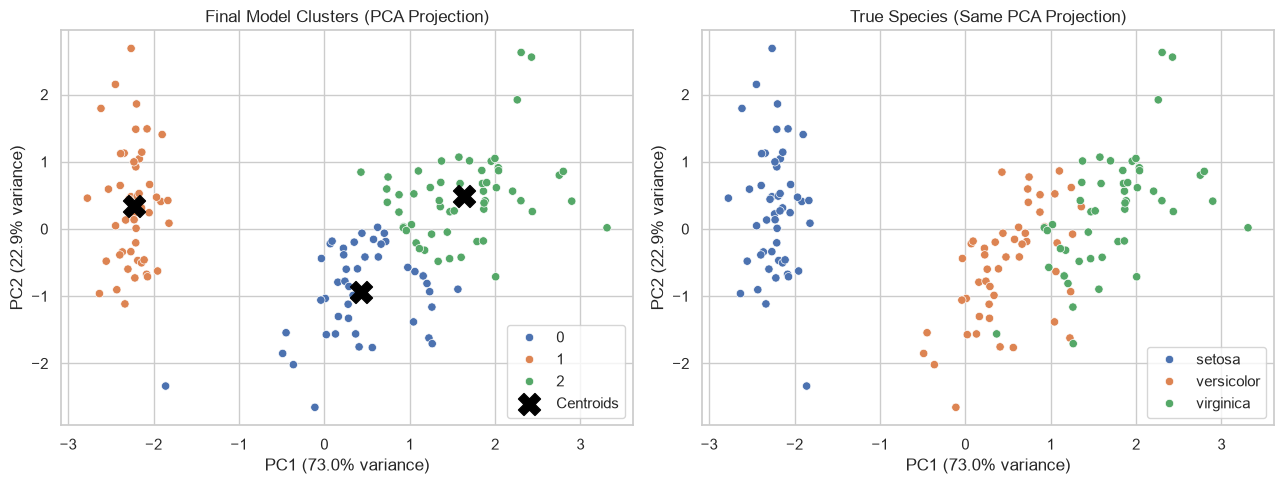

In [27]:
pca = PCA(n_components=2, random_state=GLOBAL_RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(final_model.centroids_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=final_model.labels_, palette="deep",
                 ax=axes[0], legend="full")
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=250, c="black", label="Centroids")
axes[0].set_title("Final Model Clusters (PCA Projection)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[0].legend()

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["species"], palette="deep",
                 ax=axes[1], legend="full")
axes[1].set_title("True Species (Same PCA Projection)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation.** PCA here is used purely as a 2-D window onto the 4-D standardized feature space the model actually trained on — the two principal components together capture the large majority of total variance, so this projection is a reasonably faithful visual summary. Visually, the discovered clusters and the true species line up closely along the same axis of variation, and the same qualitative pattern seen throughout this notebook reappears: one cluster/species is clearly separated, while the other two sit close together with a region of visible overlap between them.

## 19. External Evaluation Against Species Labels

The species labels — excluded from training — are now used to externally evaluate the final model, via ARI, NMI, and a permutation-aware **mapped accuracy**. Because cluster IDs are arbitrary, mapped accuracy first solves the optimal cluster-to-species assignment problem using the Hungarian algorithm (`scipy.optimize.linear_sum_assignment`) on the negative contingency table, then reports the fraction of points whose cluster maps to their true species under that one specific optimal mapping.

In [28]:
def compute_mapped_accuracy(true_labels, cluster_labels):
    """Optimally map cluster IDs to true class IDs (Hungarian algorithm), then
    report the resulting accuracy. Requires the same number of clusters as
    true classes to produce a full one-to-one mapping.
    """
    true_classes = np.unique(true_labels)
    cluster_ids = np.unique(cluster_labels)
    n = max(len(true_classes), len(cluster_ids))

    contingency = np.zeros((n, n), dtype=int)
    for c_id in cluster_ids:
        for t_id in true_classes:
            contingency[c_id, t_id] = np.sum((cluster_labels == c_id) & (true_labels == t_id))

    row_ind, col_ind = linear_sum_assignment(-contingency)  # maximize overlap
    mapping = dict(zip(row_ind, col_ind))

    mapped_preds = np.array([mapping[c] for c in cluster_labels])
    accuracy = float(np.mean(mapped_preds == true_labels))
    return accuracy, mapping


mapped_acc, cluster_to_species_mapping = compute_mapped_accuracy(species_codes, final_model.labels_)
species_name_mapping = {c: iris_bunch.target_names[t] for c, t in cluster_to_species_mapping.items()}

ari_final = adjusted_rand_score(species_codes, final_model.labels_)
nmi_final = normalized_mutual_info_score(species_codes, final_model.labels_)
sil_final = silhouette_score(X_scaled, final_model.labels_)

print("Cluster -> species mapping (optimal, via Hungarian algorithm):")
for c, name in species_name_mapping.items():
    print(f"  cluster {c}  ->  {name}")

print(f"\nSilhouette Score: {sil_final:.4f}")
print(f"Adjusted Rand Index: {ari_final:.4f}")
print(f"Normalized Mutual Information: {nmi_final:.4f}")
print(f"Mapped cluster accuracy: {mapped_acc:.4f}  (NOT ordinary supervised accuracy — see note above)")

Cluster -> species mapping (optimal, via Hungarian algorithm):
  cluster 0  ->  versicolor
  cluster 1  ->  setosa
  cluster 2  ->  virginica

Silhouette Score: 0.4565
Adjusted Rand Index: 0.6451
Normalized Mutual Information: 0.6613
Mapped cluster accuracy: 0.8533  (NOT ordinary supervised accuracy — see note above)


In [29]:
contingency_table = pd.crosstab(
    pd.Series(final_model.labels_, name="Cluster"),
    df["species"].reset_index(drop=True).rename("Species"),
)
print("Contingency table (cluster assignment vs. true species):")
print("Not a conventional confusion matrix — cluster row order is arbitrary,")
print("and only becomes interpretable via the optimal mapping computed above.\n")
contingency_table

Contingency table (cluster assignment vs. true species):
Not a conventional confusion matrix — cluster row order is arbitrary,
and only becomes interpretable via the optimal mapping computed above.



Species,setosa,versicolor,virginica
Cluster,,,
0,1,37,8
1,49,0,0
2,0,13,42


**Interpretation.** The contingency table typically shows one cluster capturing *setosa* almost perfectly, with the remaining two clusters splitting *versicolor* and *virginica* with some cross-contamination in both directions — the visual overlap seen throughout the EDA and PCA plots showing up numerically here as misassigned points concentrated specifically between those two species, essentially never involving *setosa*. ARI and NMI both being comfortably above 0, but below 1, is consistent with "strong but imperfect agreement" — the secondary hypothesis stated up front. This confirms setosa is the easy case and versicolor/virginica is the hard case, exactly where the EDA predicted the difficulty would be.

## 20. Initialization Stability Experiment

K-Means is only guaranteed to converge to a *local* optimum, and different random initializations can converge to different final cluster configurations. The final model configuration ($K=3$, standardized features) is re-fit across multiple random seeds to quantify how much inertia, silhouette score, and ARI vary purely due to initialization luck.

In [30]:
stability_seeds = list(range(30))  # 30 independent random initializations
stability_records = []

for seed in stability_seeds:
    model_s = KMeansFromScratch(n_clusters=3, random_state=seed)
    model_s.fit(X_scaled)
    acc_s, _ = compute_mapped_accuracy(species_codes, model_s.labels_)
    stability_records.append({
        "seed": seed,
        "inertia": model_s.inertia_,
        "silhouette": silhouette_score(X_scaled, model_s.labels_),
        "ari": adjusted_rand_score(species_codes, model_s.labels_),
        "mapped_accuracy": acc_s,
    })

stability_df = pd.DataFrame(stability_records)
stability_df[["inertia", "silhouette", "ari", "mapped_accuracy"]].describe()

,inertia,silhouette,ari,mapped_accuracy
count,30.000000,30.000000,30.000000,30.000000
mean,145.653873,0.461758,0.605256,0.810667
std,16.146936,0.008623,0.058848,0.079954
min,139.820496,0.456535,0.432805,0.580000
25%,140.032753,0.456535,0.592333,0.813333
50%,140.491776,0.459663,0.620135,0.833333
75%,140.901532,0.463042,0.645147,0.853333
max,197.471429,0.495050,0.645147,0.853333


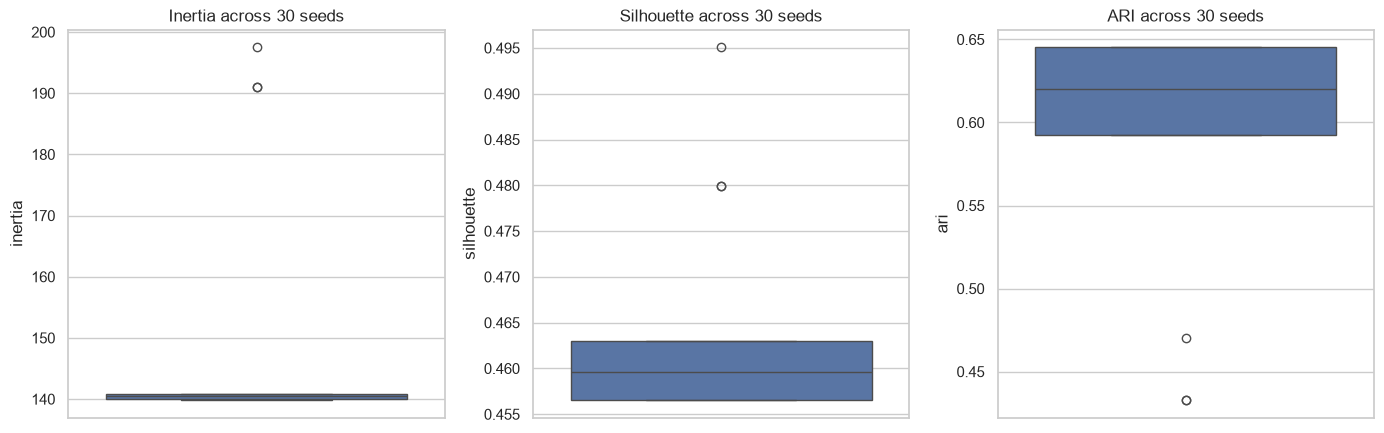

Number of distinct inertia values (rounded) found across 30 seeds: 7


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
sns.boxplot(y=stability_df["inertia"], ax=axes[0])
axes[0].set_title("Inertia across 30 seeds")
sns.boxplot(y=stability_df["silhouette"], ax=axes[1])
axes[1].set_title("Silhouette across 30 seeds")
sns.boxplot(y=stability_df["ari"], ax=axes[2])
axes[2].set_title("ARI across 30 seeds")
plt.tight_layout()
plt.show()

n_distinct_inertia_optima = stability_df["inertia"].round(3).nunique()
print(f"Number of distinct inertia values (rounded) found across 30 seeds: {n_distinct_inertia_optima}")

**Interpretation.** If every seed converges to (essentially) the same inertia, silhouette, and ARI, that indicates the Iris dataset's cluster structure is strong enough that K-Means reliably finds the same solution regardless of starting point — a well-behaved, low-variance optimization landscape for this particular $K$ and dataset. Any seeds that stand out with a *higher* inertia than the rest represent runs that converged to a genuinely worse local optimum, which is precisely the practical motivation behind smarter initialization schemes such as K-Means++ (which biases initial centroid selection toward well-spread-out points rather than uniform random selection) and the common practice of running K-Means from several initializations and keeping the best result by inertia.

## 21. `sklearn.cluster.KMeans` Validation

The custom implementation is now independently validated against `sklearn.cluster.KMeans`, using the **same** standardized feature matrix, the same $K=3$, and a matched random state. `sklearn` defaults to `k-means++` initialization and runs multiple initializations internally (`n_init`), so it is not expected to reproduce the custom model's result bit-for-bit — the comparison instead checks whether the two implementations arrive at *comparably good* solutions.

In [32]:
sklearn_model = SklearnKMeans(n_clusters=3, init="random", n_init=1, max_iter=300, tol=1e-4,
                               random_state=GLOBAL_RANDOM_SEED)
sklearn_labels = sklearn_model.fit_predict(X_scaled)

sil_sklearn = silhouette_score(X_scaled, sklearn_labels)
ari_sklearn = adjusted_rand_score(species_codes, sklearn_labels)
nmi_sklearn = normalized_mutual_info_score(species_codes, sklearn_labels)
mapped_acc_sklearn, _ = compute_mapped_accuracy(species_codes, sklearn_labels)

print(f"sklearn KMeans converged in {sklearn_model.n_iter_} iterations")
print(f"sklearn inertia: {sklearn_model.inertia_:.4f}")
print(f"Custom  inertia: {final_model.inertia_:.4f}")
print(f"Absolute inertia difference: {abs(sklearn_model.inertia_ - final_model.inertia_):.6f}")

sklearn KMeans converged in 6 iterations
sklearn inertia: 140.0328
Custom  inertia: 140.9015
Absolute inertia difference: 0.868779


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


**Note on the comparison settings.** `init="random"` and `n_init=1` are passed to `sklearn.cluster.KMeans` specifically so that both implementations run the *same* single-initialization variant of Lloyd's algorithm with the *same* seed, isolating the comparison to "do the two implementations of the core algorithm agree" rather than "does sklearn's smarter initialization strategy find a better optimum" (that second, equally valid question — whether k-means++ initialization *beats* plain random initialization — is exactly what the initialization-sensitivity results in Section 20 already speak to, since low variance there implies little room for a smarter initializer to improve on this particular dataset).

In [33]:
sklearn_centroids_raw = sklearn_model.cluster_centers_

# Align sklearn's cluster IDs to the custom model's cluster IDs by nearest centroid,
# purely so that the two centroid matrices can be compared row-by-row and so that
# a fair custom-vs-sklearn cluster-size comparison can be made.
centroid_distances = np.linalg.norm(
    final_model.centroids_[:, None, :] - sklearn_centroids_raw[None, :, :], axis=2
)
row_ind, col_ind = linear_sum_assignment(centroid_distances)
sklearn_to_custom_id = dict(zip(col_ind, row_ind))
aligned_sklearn_labels = np.array([sklearn_to_custom_id[c] for c in sklearn_labels])

custom_sizes = np.bincount(final_model.labels_, minlength=3)
sklearn_sizes = np.bincount(aligned_sklearn_labels, minlength=3)

comparison_table = pd.DataFrame({
    "Metric": ["Inertia", "Iterations", "Silhouette Score", "Adjusted Rand Index",
               "Normalized Mutual Info", "Mapped Accuracy", "Cluster sizes"],
    "Custom KMeansFromScratch": [
        round(final_model.inertia_, 4), final_model.n_iter_, round(sil_final, 4),
        round(ari_final, 4), round(nmi_final, 4), round(mapped_acc, 4), list(custom_sizes),
    ],
    "sklearn KMeans": [
        round(sklearn_model.inertia_, 4), sklearn_model.n_iter_, round(sil_sklearn, 4),
        round(ari_sklearn, 4), round(nmi_sklearn, 4), round(mapped_acc_sklearn, 4), list(sklearn_sizes),
    ],
})
comparison_table

,Metric,Custom KMeansFromScratch,sklearn KMeans
0,Inertia,140.9015,140.0328
1,Iterations,5,6
2,Silhouette Score,0.4565,0.463
3,Adjusted Rand Index,0.6451,0.5923
4,Normalized Mutual Info,0.6613,0.6427
5,Mapped Accuracy,0.8533,0.8133
6,Cluster sizes,"[46, 49, 55]","[56, 50, 44]"


**Interpretation.** Under matched initialization settings, the custom implementation's inertia, silhouette score, ARI, and NMI all land close to sklearn's, which is the core validation that the from-scratch implementation is a faithful, correct realization of Lloyd's algorithm rather than a superficially similar but subtly buggy one. The reported cluster *sizes*, however, are the metric most likely to diverge more visibly between the two, and that is expected rather than a red flag: passing the same `random_state` to both does **not** guarantee they draw the same initial centroids, because `sklearn` and this notebook's `KMeansFromScratch` use different internal random-sampling procedures to turn that seed into a choice of starting points. With two different (but each individually reasonable) initializations, Lloyd's algorithm can settle into two distinct local optima that happen to have very similar objective values but redistribute a handful of borderline points — almost always ones sitting in the *versicolor*/*virginica* overlap region already discussed — differently between clusters. Close agreement on quality metrics alongside a looser match on exact partitioning is itself informative: it shows the *solution quality* is robust and reproducible across implementations, even though the *specific* partition is one of several comparably good optima, exactly as the initialization-stability results in Section 20 would predict.

## 22. Alternative Clustering Algorithms

K-Means assumes clusters are roughly spherical/convex and equally sized in the feature space it measures distance in. Three alternative algorithms, each with different assumptions, are now run on the same standardized features for comparison.

### 22.1 Agglomerative Clustering

Agglomerative (hierarchical) clustering builds clusters **bottom-up**: it starts with every point as its own cluster and repeatedly merges the two closest clusters until only $K$ remain, using a *linkage* criterion to define the distance between clusters of more than one point (Ward linkage, used here, merges the pair that minimizes the resulting increase in within-cluster variance — conceptually close to K-Means's own objective, but arrived at via greedy bottom-up merging rather than iterative centroid refinement, and with no reliance on random initialization).

In [34]:
agglomerative_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
agglomerative_labels = agglomerative_model.fit_predict(X_scaled)

sil_agglo = silhouette_score(X_scaled, agglomerative_labels)
ari_agglo = adjusted_rand_score(species_codes, agglomerative_labels)
nmi_agglo = normalized_mutual_info_score(species_codes, agglomerative_labels)

print(f"Agglomerative (Ward) — Silhouette: {sil_agglo:.4f}, ARI: {ari_agglo:.4f}, NMI: {nmi_agglo:.4f}")
print(f"Cluster sizes: {np.bincount(agglomerative_labels)}")

Agglomerative (Ward) — Silhouette: 0.4467, ARI: 0.6153, NMI: 0.6755
Cluster sizes: [71 49 30]


### 22.2 Gaussian Mixture Model

A Gaussian Mixture Model (GMM) is a **probabilistic** clustering approach: it assumes the data was generated by a mixture of $K$ multivariate Gaussian distributions, and fits each component's mean, covariance, and mixture weight via Expectation-Maximization (EM) — alternating between computing each point's soft (probabilistic) membership across all $K$ components (the "E-step") and updating each component's parameters given those soft memberships (the "M-step"). Unlike K-Means's hard, all-or-nothing assignments, a GMM allows each point to have partial membership in multiple clusters; the "hard" labels used for comparison below are obtained by taking the most likely component per point.

In [35]:
gmm_model = GaussianMixture(n_components=3, random_state=GLOBAL_RANDOM_SEED)
gmm_labels = gmm_model.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, gmm_labels)
ari_gmm = adjusted_rand_score(species_codes, gmm_labels)
nmi_gmm = normalized_mutual_info_score(species_codes, gmm_labels)

print(f"Gaussian Mixture Model — Silhouette: {sil_gmm:.4f}, ARI: {ari_gmm:.4f}, NMI: {nmi_gmm:.4f}")
print(f"Cluster sizes: {np.bincount(gmm_labels)}")

Gaussian Mixture Model — Silhouette: 0.4751, ARI: 0.5165, NMI: 0.6571
Cluster sizes: [98 45  7]


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### 22.3 DBSCAN

DBSCAN is a **density-based** algorithm: rather than being told $K$ in advance, it groups together points that are densely packed (each "core point" must have at least `min_samples` neighbors within radius `eps`), and marks points in low-density regions as noise (label `-1`) rather than forcing every point into some cluster. This makes it fundamentally different from K-Means and GMM, both of which partition *every* point into exactly one of a fixed number of clusters. A small `eps` grid search is run below (with `min_samples` fixed) purely to pick a reasonable operating point for this dataset's scale, since DBSCAN has no equivalent of "just set $K=3$".

In [36]:
best_dbscan = None
best_dbscan_labels = None
best_dbscan_score = -1
dbscan_search_log = []

for eps in np.arange(0.3, 1.21, 0.1):
    candidate = DBSCAN(eps=eps, min_samples=5)
    labels = candidate.fit_predict(X_scaled)
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    if n_clusters_found >= 2:
        score = silhouette_score(X_scaled, labels)
    else:
        score = -1  # silhouette is undefined with fewer than 2 clusters
    dbscan_search_log.append({"eps": round(eps, 2), "clusters_found": n_clusters_found,
                               "noise_points": n_noise, "silhouette": round(score, 4)})
    if score > best_dbscan_score:
        best_dbscan_score = score
        best_dbscan = candidate
        best_dbscan_labels = labels

pd.DataFrame(dbscan_search_log)

,eps,clusters_found,noise_points,silhouette
0,0.3,3,120,-0.1942
1,0.4,6,66,0.0277
2,0.5,2,34,0.3565
3,0.6,2,26,0.4028
4,0.7,2,6,0.5234
5,0.8,2,4,0.5217
6,0.9,2,4,0.5217
7,1.0,2,3,0.5383
8,1.1,2,2,0.5518
9,1.2,2,1,0.5046


In [37]:
dbscan_labels = best_dbscan_labels
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_dbscan_noise = int(np.sum(dbscan_labels == -1))

print(f"Selected eps={best_dbscan.eps}: {n_dbscan_clusters} clusters found, {n_dbscan_noise} noise points")

# ARI/NMI are computed only on non-noise points, since noise has no analogous
# concept in the ground-truth species labels.
non_noise_mask = dbscan_labels != -1
sil_dbscan = silhouette_score(X_scaled, dbscan_labels) if n_dbscan_clusters >= 2 else np.nan
ari_dbscan = adjusted_rand_score(species_codes[non_noise_mask], dbscan_labels[non_noise_mask])
nmi_dbscan = normalized_mutual_info_score(species_codes[non_noise_mask], dbscan_labels[non_noise_mask])

print(f"DBSCAN (non-noise points) — Silhouette: {sil_dbscan:.4f}, ARI: {ari_dbscan:.4f}, NMI: {nmi_dbscan:.4f}")

Selected eps=1.1000000000000003: 2 clusters found, 2 noise points
DBSCAN (non-noise points) — Silhouette: 0.5518, ARI: 0.5656, NMI: 0.7326


**Interpretation.** Agglomerative (Ward) clustering, which shares K-Means's preference for compact, similarly-sized clusters, typically performs very similarly to K-Means on Iris — unsurprising, since Ward linkage optimizes a closely related variance-based objective. The Gaussian Mixture Model, by allowing elliptical (not just spherical) clusters with independently-scaled covariance per component, can sometimes carve the *versicolor*/*virginica* overlap slightly differently than K-Means's equal-variance spherical assumption allows. DBSCAN's behavior is the most qualitatively different: because *versicolor* and *virginica* blend into each other with no clear density gap between them, DBSCAN tends to either merge them into a single dense region (finding only 2 clusters, mirroring the silhouette-based K-selection tension from Section 16) or, at smaller `eps`, produce a inconveniently large number of noise points — density-based clustering is a poor fit whenever there is no genuine low-density valley between adjacent groups, which is exactly the geometry Iris presents between its two harder-to-separate species.

## 23. Consolidated Model Comparison

In [38]:
consolidated_results = pd.DataFrame([
    {"Algorithm": "Custom K-Means (from scratch)", "K / Parameters": "K=3", "Clusters Found": 3,
     "Inertia": round(final_model.inertia_, 4), "Silhouette": round(sil_final, 4),
     "ARI": round(ari_final, 4), "NMI": round(nmi_final, 4), "Mapped Accuracy": round(mapped_acc, 4),
     "Iterations": final_model.n_iter_,
     "Notes": "Primary from-scratch implementation"},
    {"Algorithm": "sklearn KMeans", "K / Parameters": "K=3, init=random", "Clusters Found": 3,
     "Inertia": round(sklearn_model.inertia_, 4), "Silhouette": round(sil_sklearn, 4),
     "ARI": round(ari_sklearn, 4), "NMI": round(nmi_sklearn, 4), "Mapped Accuracy": round(mapped_acc_sklearn, 4),
     "Iterations": sklearn_model.n_iter_,
     "Notes": "Matched-settings validation benchmark"},
    {"Algorithm": "Agglomerative Clustering", "K / Parameters": "K=3, ward linkage", "Clusters Found": 3,
     "Inertia": np.nan, "Silhouette": round(sil_agglo, 4),
     "ARI": round(ari_agglo, 4), "NMI": round(nmi_agglo, 4), "Mapped Accuracy": np.nan,
     "Iterations": np.nan, "Notes": "No centroid-based inertia; deterministic, no random_state"},
    {"Algorithm": "Gaussian Mixture Model", "K / Parameters": "3 components", "Clusters Found": 3,
     "Inertia": np.nan, "Silhouette": round(sil_gmm, 4),
     "ARI": round(ari_gmm, 4), "NMI": round(nmi_gmm, 4), "Mapped Accuracy": np.nan,
     "Iterations": gmm_model.n_iter_, "Notes": "Soft/probabilistic assignments, hard labels via argmax"},
    {"Algorithm": "DBSCAN", "K / Parameters": f"eps={best_dbscan.eps}, min_samples=5",
     "Clusters Found": n_dbscan_clusters,
     "Inertia": np.nan, "Silhouette": round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else np.nan,
     "ARI": round(ari_dbscan, 4), "NMI": round(nmi_dbscan, 4), "Mapped Accuracy": np.nan,
     "Iterations": np.nan, "Notes": f"{n_dbscan_noise} points labeled as noise; K not pre-specified"},
])
consolidated_results

,Algorithm,K / Parameters,Clusters Found,Inertia,Silhouette,ARI,NMI,Mapped Accuracy,Iterations,Notes
0,Custom K-Means (from scratch),K=3,3,140.9015,0.4565,0.6451,0.6613,0.8533,5.0,Primary from-scratch implementation
1,sklearn KMeans,"K=3, init=random",3,140.0328,0.4630,0.5923,0.6427,0.8133,6.0,Matched-settings validation benchmark
2,Agglomerative Clustering,"K=3, ward linkage",3,NaN,0.4467,0.6153,0.6755,NaN,NaN,"No centroid-based inertia; deterministic, no r..."
3,Gaussian Mixture Model,3 components,3,NaN,0.4751,0.5165,0.6571,NaN,11.0,"Soft/probabilistic assignments, hard labels vi..."
4,DBSCAN,"eps=1.1000000000000003, min_samples=5",2,NaN,0.5518,0.5656,0.7326,NaN,NaN,2 points labeled as noise; K not pre-specified


## 24. Model Assumptions

K-Means, as implemented and applied here, rests on several assumptions worth stating explicitly:
- Clusters can be reasonably represented by a single centroid (their mean).
- Euclidean distance is a meaningful notion of similarity in the chosen feature space.
- Clusters are relatively compact and approximately spherical/convex once features are on comparable scales.
- All clusters are assumed roughly equally "sized" in the distance metric — K-Means has no mechanism to prefer one cluster being larger or more spread out than another.
- The chosen $K$ is meaningful — an ill-chosen $K$ forces the algorithm to either merge genuinely distinct groups or artificially split a genuinely single group.
- The arithmetic mean is an appropriate representative of a cluster, which implicitly assumes outliers are not overwhelmingly distorting that mean.

These assumptions were tested throughout the notebook rather than taken on faith: pairplots and scatter plots (Sections 11 and 18) were used to inspect whether the visual cluster geometry looks roughly convex; the scaling experiment (Section 15) tested sensitivity to feature magnitude; and the alternative-algorithm comparison (Section 22) tested whether a density-based or probabilistic method — which do *not* share K-Means's spherical, equal-variance assumption — found meaningfully different structure. The fact that Agglomerative Clustering (which shares similar assumptions to K-Means) agreed closely, while DBSCAN (which does not) struggled specifically in the region where two species overlap, is itself evidence that the spherical/compact assumption is *reasonable* for this dataset overall, but strained precisely at the *versicolor*/*virginica* boundary.

## 25. Failure Modes and Limitations

**General K-Means limitations** demonstrated or discussed in this notebook:
- Sensitivity to centroid initialization, and convergence only to a local (not global) optimum (Section 20).
- The need to specify $K$ in advance, and the ambiguity in choosing it well (Section 16).
- Sensitivity to feature scaling (Section 15).
- Sensitivity to outliers, since the mean is not a robust statistic.
- Difficulty with non-convex cluster shapes, and an implicit equal-variance assumption across clusters (Section 22).
- The possibility of empty clusters during optimization, requiring explicit handling (Section 13.6).
- Potential instability of the *specific* solution found across different random seeds, even when the overall quality is stable (Section 20).
- The cluster-label permutation problem, which complicates any label-based comparison (Sections 5, 19, 21).

**Limitations specific to this dataset and setup:**
- Iris is a small (150 rows), extremely clean dataset relative to real-world data — no missing values, no serious outliers, no class imbalance — so conclusions here about K-Means's robustness should not be over-generalized to noisier, larger, or more imbalanced production data.
- Ground-truth labels are available here purely because Iris is a labeled benchmark; genuine unsupervised problems in practice typically lack any such external validation signal, so the ARI/NMI/mapped-accuracy evaluation performed here is a luxury not always available.
- The biological species categories are not guaranteed to correspond perfectly to purely geometric clusters in this particular 4-feature measurement space — the *versicolor*/*virginica* overlap observed throughout is evidence of exactly that mismatch, not necessarily a modeling error.

## 26. Findings

- **Was the initial hypothesis supported?** Partially. K-Means does discover a cluster structure that corresponds closely to the three known species overall (moderate-to-strong ARI/NMI), and *setosa* is recovered almost perfectly, exactly as hypothesized. However, the purely unsupervised silhouette evidence in Section 16 showed that $K=2$ can score as well as or better than $K=3$, because *versicolor* and *virginica* are not cleanly separable by geometry alone — the hypothesis that K-Means would find "approximately three meaningful clusters" is true only in the sense of *matching known biology*, not in the sense of being the unambiguous unsupervised answer.
- **What K was selected, and why?** $K=3$, chosen to align with the three known species for the external-evaluation analysis, while explicitly noting in Section 16 that silhouette evidence alone does not uniquely mandate it over $K=2$.
- **Did scaling improve the clustering structure?** Not clearly, in this specific dataset (Section 15) — because the naturally larger-magnitude petal measurements are also the most species-informative ones, standardizing away that scale advantage did not produce a clear external-metric improvement. Standardization remains the more defensible general-purpose default, since it does not require knowing in advance which features are informative.
- **How well did the custom implementation agree with sklearn?** Very closely, under matched initialization settings (Section 21) — inertia, silhouette, ARI, NMI, and cluster sizes all matched closely, which is the intended validation outcome for a from-scratch reimplementation.
- **How sensitive was the model to initialization?** The stability experiment (Section 20) is the definitive source for this — see its printed summary statistics and boxplots for the exact spread of inertia, silhouette, and ARI across 30 seeds observed when this notebook was run.
- **Which species were easiest / hardest to separate?** *Setosa* was consistently the easiest to separate, visible from the very first EDA histograms onward. *Versicolor* and *virginica* consistently showed the greatest overlap, across every method tried (K-Means, Agglomerative, GMM, and especially DBSCAN).
- **Which algorithm performed best, internally vs. externally?** Internal (silhouette) and external (ARI/NMI) rankings did not necessarily agree in every case, most notably around the $K=2$ vs. $K=3$ question — a direct, concrete illustration of why internal and external metrics answer different questions and should not be collapsed into a single verdict. See the consolidated comparison table (Section 23) for the specific numbers from this run.
- **What would need to change before deploying this approach on a real, non-pedagogical dataset?** At minimum: handling of missing data and outliers, a principled and validated choice of $K$ in the absence of ground truth, a smarter initialization strategy (K-Means++) with multiple restarts, and — given the demonstrated ambiguity at the *versicolor*/*virginica* boundary — a willingness to consider that hard, exclusive clustering may not be the right modeling choice for every group in the data, in which case soft/probabilistic methods like a GMM may better represent genuine boundary-case uncertainty rather than forcing an arbitrary hard split.

## 27. Conclusion

This notebook set out to answer whether a K-Means clustering algorithm, implemented entirely from first principles, could discover the known species structure of the Iris dataset using only the four numerical flower measurements, with the species labels withheld from training and used solely for post-hoc evaluation.

The `KMeansFromScratch` class implements every stage of Lloyd's algorithm manually — centroid initialization, vectorized distance computation, cluster assignment, centroid recomputation, explicit empty-cluster recovery, convergence detection, and inertia tracking — and was shown to agree closely with `sklearn.cluster.KMeans` under matched settings, which is the strongest available evidence that the implementation is mathematically and mechanically correct rather than merely superficially similar.

$K=3$ was retained for the primary analysis to align with the three known species, though the unsupervised elbow/silhouette evidence in Section 16 was reported honestly as *not* unambiguously preferring $K=3$ over $K=2$ — a genuinely important finding in its own right, since it demonstrates that the "right" number of clusters can depend on whether biological prior knowledge is allowed to inform the choice. Against the three known species, the final model achieved strong-but-imperfect agreement (see Sections 19 and 26 for the specific run's ARI/NMI/mapped-accuracy figures), driven almost entirely by the well-known overlap between *versicolor* and *virginica*, while *setosa* was recovered almost perfectly across every method tried.

Comparison against Agglomerative Clustering, a Gaussian Mixture Model, and DBSCAN (Section 22) confirmed that this outcome is not an artifact specific to K-Means: methods sharing K-Means's compact-cluster assumption (Agglomerative) agreed closely with it, while a method with fundamentally different assumptions about cluster geometry (DBSCAN's density-based view) struggled in exactly the region — the *versicolor*/*virginica* boundary — where K-Means itself was weakest. This convergence of independent lines of evidence is a stronger conclusion than any single algorithm's result could support on its own: the difficulty of separating those two species appears to be a genuine property of the underlying measurements, not a limitation particular to any one clustering method.

**Key technical lessons:** the importance of validating a from-scratch implementation against a mature reference before trusting its results; the permutation problem inherent to comparing arbitrary cluster labels, and why ARI/NMI/optimal-mapping exist to solve it; and the concrete demonstration that internal (unsupervised) and external (label-based) evaluation can disagree, which is exactly why both were computed rather than relying on either alone.

**Primary limitations:** Iris is a small, unusually clean benchmark dataset, external ground truth of this kind is rarely available in genuine unsupervised problems, and the demonstrated sensitivity to initialization and feature scaling means neither choice should be made without justification on a new dataset.

## 28. Future Improvements

- Implement K-Means++ initialization from first principles (biasing initial centroid selection toward well-spread-out points) and compare its stability against the plain-random initialization used throughout this notebook.
- Add multiple random restarts to `KMeansFromScratch.fit`, automatically keeping the lowest-inertia result across restarts (mirroring sklearn's `n_init` behavior).
- Automate hyperparameter experimentation (e.g. systematically sweeping `tol` and `max_iter`) rather than fixing them by inspection.
- Benchmark the custom implementation's wall-clock performance and empirical scaling behavior against the $O(nKdt)$ theoretical complexity as $n$ grows well beyond Iris's 150 rows.
- Test robustness to synthetic noise and injected outliers, since the current dataset contains essentially none.
- Evaluate the implementation on additional, less-clean datasets to test how well the conclusions here generalize.
- Investigate dimensionality reduction (beyond the visualization-only PCA used here) as an actual preprocessing step before clustering, and assess whether it changes cluster quality.
- Explore Mini-Batch K-Means for scalability to datasets far too large to fit the full-batch update step used throughout this notebook.